# ResQNet: 3D Disaster City Wireless Propagation & UAV Optimization Demo
### User / PC Profile: **Rayaan**
---
This Jupyter Notebook demonstrates the physical 3D environment, PPO-selected UAV base station placement, 10 ground survivor locations, and real-time **Sionna RT 3D ray-tracing propagation**.

In [1]:
# Setup paths and imports
import os
import sys
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Add project directories to sys.path
cwd = Path.cwd()
if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))
if str(cwd / 'sionna') not in sys.path:
    sys.path.insert(0, str(cwd / 'sionna'))
if str(cwd / 'ml') not in sys.path:
    sys.path.insert(0, str(cwd / 'ml'))

import sionna.rt
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver
from sionna_feedback_engine import DEFAULT_10_USERS, ConnectivityConfig, evaluate_uav_position
print("All ResQNet modules successfully loaded!")

jitc_llvm_init(): LLVM API initialization failed ..


All ResQNet modules successfully loaded!


## 1. Load 3D Damaged Urban Environment Mesh
Loads the official 560k-polygon 3D damaged city mesh (`city_damaged.xml`).

In [2]:
scene_path = Path('sionna/scenes/city_damaged.xml')
if not scene_path.exists():
    scene_path = Path('scenes/city_damaged.xml')

print(f"Loading 3D Damaged City Mesh from: {scene_path}...")
scene = load_scene(str(scene_path))

for name, obj in scene.objects.items():
    if obj.radio_material is None:
        obj.radio_material = "itu_concrete"

scene.frequency = 2.1e9

# Configure PlanarArray Antennas (Isotropic, Vertical Polarization)
scene.tx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="iso", polarization="V"
)
scene.rx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="iso", polarization="V"
)
print(f"Scene loaded successfully! Number of 3D objects: {len(scene.objects)}")

Loading 3D Damaged City Mesh from: sionna\scenes\city_damaged.xml...
Scene loaded successfully! Number of 3D objects: 1


## 2. Deploy PPO-Optimized UAV & 10 Ground Survivor Nodes
Loads the UAV coordinate selected by the PPO reinforcement learning agent (`data/uav_positions.json`) and places the 10 ground users.

In [3]:
# Load PPO position
uav_json = Path('data/uav_positions.json')
uav_pos = [-15.0, 30.0, 12.0]
if uav_json.exists():
    try:
        with open(uav_json, 'r') as f:
            data = json.load(f)
            if 'uav_positions' in data and len(data['uav_positions']) > 0:
                uav_pos = data['uav_positions'][0]
    except Exception:
        pass

uav_pos = [float(uav_pos[0]), float(uav_pos[1]), float(uav_pos[2])]
print(f"PPO-Selected UAV Position: [X={uav_pos[0]:.2f}m, Y={uav_pos[1]:.2f}m, Z={uav_pos[2]:.2f}m]")

# Clear existing transmitters & receivers
for name in list(scene.transmitters.keys()):
    scene.remove(name)
for name in list(scene.receivers.keys()):
    scene.remove(name)

# Add UAV transmitter
uav = Transmitter(name="PPO_UAV_Rayaan", position=uav_pos)
scene.add(uav)

# Add 10 Ground Users
user_positions = DEFAULT_10_USERS
for i, pos in enumerate(user_positions):
    rx = Receiver(name=f"User_{i+1}", position=[float(pos[0]), float(pos[1]), float(pos[2])])
    scene.add(rx)

print(f"Deployed 1 UAV transmitter and {len(user_positions)} ground receivers.")

PPO-Selected UAV Position: [X=-29.31m, Y=22.64m, Z=25.97m]
Deployed 1 UAV transmitter and 10 ground receivers.


## 3. Compute Sionna RT 3D Ray Tracing Channel Propagation
Executes the Mitsuba 3 / Sionna RT `PathSolver` to trace direct Line-of-Sight and multipath reflection paths.

In [4]:
print("Computing 3D Ray Tracing Channel Paths (Shoot-and-Bounce Rays)...")
solver = PathSolver()
paths = solver(scene, max_depth=3, seed=42)

# Evaluate physical QoS wireless metrics
qos_config = ConnectivityConfig(rss_threshold_dbm=-50.0, enable_sinr=True)
res = evaluate_uav_position(
    uav_pos,
    user_positions=user_positions,
    scene_name="city_damaged.xml",
    connectivity_config=qos_config
)
agg = res["aggregate"]

print("\n" + "=" * 75)
print("PHYSICAL WIRELESS PROPAGATION TELEMETRY")
print("=" * 75)
print(f"Connected Users           : {agg['connected_users_count']} / 10 ({agg['connected_users_percentage']}%)")
print(f"Spatial Coverage          : {agg['coverage_percentage']:.1f}%")
print(f"Mean Received Power (RSS) : {agg['mean_rss_dbm']:.2f} dBm")
print(f"Mean SNR                  : {agg['mean_sinr_db']:.2f} dB (Thermal noise floor = -94 dBm, I = 0)")

Computing 3D Ray Tracing Channel Paths (Shoot-and-Bounce Rays)...

PHYSICAL WIRELESS PROPAGATION TELEMETRY
Connected Users           : 10 / 10 (100.0%)
Spatial Coverage          : 100.0%
Mean Received Power (RSS) : -44.54 dBm
Mean SNR                  : 49.46 dB (Thermal noise floor = -94 dBm, I = 0)


## 4. Per-User Link Diagnostics Breakdown

In [5]:
print(f"{'User ID':<8} | {'3D Position [X, Y, Z]':<22} | {'RSS (dBm)':<12} | {'SNR (dB)':<10} | {'Paths':<6} | {'Status':<10}")
print("-" * 75)
for u in res["user_results"]:
    pos_str = f"[{u['position'][0]:.0f}, {u['position'][1]:.0f}, {u['position'][2]:.1f}]"
    status_str = "CONNECTED" if u["connected"] else "DISCONNECTED"
    print(f"{u['user_id']:<8} | {pos_str:<22} | {u['rss_dbm']:<12.2f} | {u['sinr_db']:<10.2f} | {u['num_paths']:<6} | {status_str:<10}")

User ID  | 3D Position [X, Y, Z]  | RSS (dBm)    | SNR (dB)   | Paths  | Status    
---------------------------------------------------------------------------
user_1   | [-20, -30, 1.5]        | -44.28       | 49.72      | 3      | CONNECTED 
user_2   | [-10, -20, 1.5]        | -43.31       | 50.69      | 3      | CONNECTED 
user_3   | [0, -10, 1.5]          | -42.91       | 51.09      | 2      | CONNECTED 
user_4   | [10, 0, 1.5]           | -45.59       | 48.41      | 3      | CONNECTED 
user_5   | [20, 10, 1.5]          | -46.40       | 47.60      | 4      | CONNECTED 
user_6   | [-15, 25, 1.5]         | -40.58       | 53.42      | 3      | CONNECTED 
user_7   | [5, 35, 1.5]           | -49.80       | 44.20      | 2      | CONNECTED 
user_8   | [25, -15, 1.5]         | -48.46       | 45.54      | 5      | CONNECTED 
user_9   | [-30, -10, 1.5]        | -40.81       | 53.19      | 3      | CONNECTED 
user_10  | [0, 20, 1.5]           | -43.25       | 50.75      | 2      | CONNECTED 


## 5. Render 3D Urban Ray-Tracing Visualization
Generates a 3D visualization showing UAV altitude, 10 ground survivor nodes, and 3D propagation ray paths.

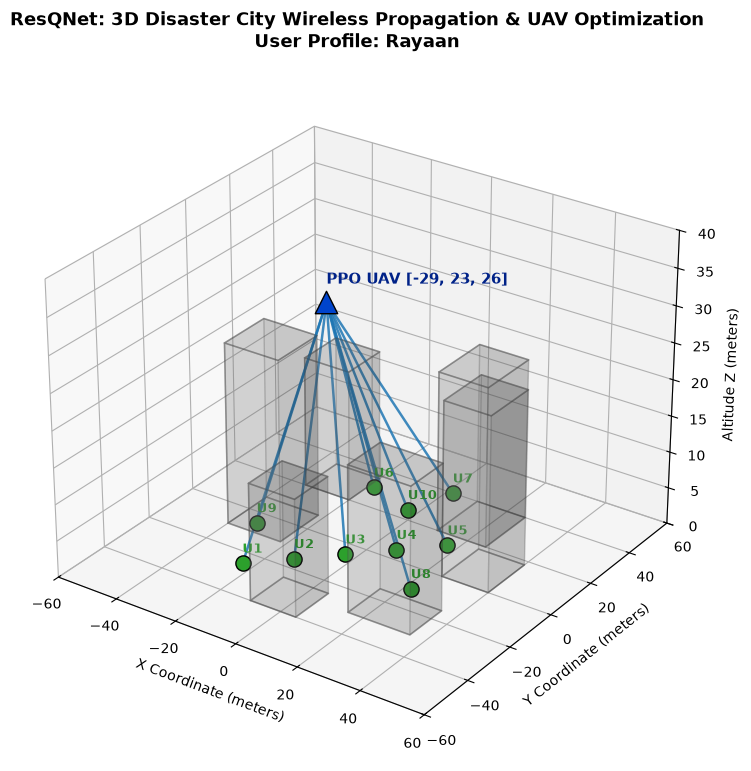

In [6]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Draw representative building structures
building_blocks = [
    (-40, -10, 0, 18, 18, 25),
    (10, 20, 0, 16, 20, 22),
    (-35, 20, 0, 15, 15, 18),
    (15, -30, 0, 20, 15, 20),
    (-10, -40, 0, 15, 15, 16),
    (25, 0, 0, 15, 18, 24),
]
for bx, by, bz, dx, dy, dz in building_blocks:
    xx = [bx, bx+dx, bx+dx, bx, bx, bx, bx+dx, bx+dx, bx, bx]
    yy = [by, by, by+dy, by+dy, by, by, by, by+dy, by+dy, by]
    zz = [bz, bz, bz, bz, bz, bz+dz, bz+dz, bz+dz, bz+dz, bz+dz]
    ax.plot(xx, yy, zz, color='#555555', alpha=0.45, linewidth=1.2)
    ax.bar3d(bx, by, bz, dx, dy, dz, color='#7f7f7f', alpha=0.15, edgecolor='#444444')

# Plot Ground Users and 3D propagation rays
for idx, (ux, uy, uz) in enumerate(user_positions):
    is_conn = res['user_results'][idx]['connected']
    u_col = '#2ca02c' if is_conn else '#d62728'
    ax.scatter(ux, uy, uz, color=u_col, s=120, marker='o', edgecolor='black', zorder=10)
    ax.text(ux, uy, uz + 1.5, f"U{idx+1}", fontsize=9, fontweight='bold', color=u_col)
    line_style = '-' if is_conn else '--'
    line_alpha = 0.85 if is_conn else 0.35
    line_color = '#1f77b4' if is_conn else '#d62728'
    ax.plot([uav_pos[0], ux], [uav_pos[1], uy], [uav_pos[2], uz],
            color=line_color, linestyle=line_style, alpha=line_alpha, linewidth=1.8)

# Plot UAV Base Station
ax.scatter(uav_pos[0], uav_pos[1], uav_pos[2], color='#0044cc', s=260, marker='^', edgecolor='black', zorder=15)
ax.text(uav_pos[0], uav_pos[1], uav_pos[2] + 2.5, f"PPO UAV [{uav_pos[0]:.0f}, {uav_pos[1]:.0f}, {uav_pos[2]:.0f}]",
        fontsize=11, fontweight='bold', color='#002288')

ax.set_title("ResQNet: 3D Disaster City Wireless Propagation & UAV Optimization\nUser Profile: Rayaan", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("X Coordinate (meters)")
ax.set_ylabel("Y Coordinate (meters)")
ax.set_zlabel("Altitude Z (meters)")
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_zlim(0, 40)
ax.view_init(elev=28, azim=-55)
plt.show()

## 6. Launch Interactive Sionna 3D Viewer
Opens the interactive renderer window (rotate with Left-Click, pan with Right-Click, zoom with Scroll).

In [7]:
print("Launching Interactive Sionna 3D Viewer...")
scene.preview(paths=paths, resolution=(1024, 768))

Launching Interactive Sionna 3D Viewer...
